## Simulated dataset and simple linear regression example

In [14]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [15]:
#Set the random number generator
rng = np.random.RandomState(42)

In [16]:
# Random values in a given shape
x = 10 * rng.rand(50)

In [17]:
# Return a sample (or samples) from the “standard normal” distribution
y = 2 * x -1 + rng.randn(50)

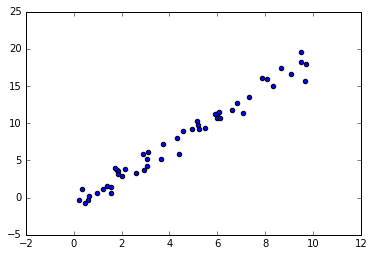

In [18]:
plt.scatter(x, y)

In [56]:
from sklearn.linear_model import LinearRegression
# Declare model:
linear_model = LinearRegression(fit_intercept=True)
# Fit model:
results = linear_model.fit(np.expand_dims(x,1), np.expand_dims(y,1))
print( results.intercept_ )
print( results.coef_ )
# Stats models is a more complete verison 
import statsmodels.api as sm
# Fit and summarize OLS model
linear_model2 = sm.OLS(x, y)
results2 = linear_model2.fit()
print( results2.summary() )

[-0.90331073]
[[ 1.9776566]]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     4360.
Date:                Tue, 10 Jul 2018   Prob (F-statistic):           1.51e-49
Time:                        21:18:22   Log-Likelihood:                -41.816
No. Observations:                  50   AIC:                             85.63
Df Residuals:                      49   BIC:                             87.55
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5392  

# Simple Linear Regression

Simple linear regression is a straight forward approach for predicting a quantivitative response $ y $ on the basis of a predictor varaible $ x $. The assumption here is that the relationship between x and y is linear, or approximately linear. Mathematically this translates to y approximately regressing onto x.

$Y \approx \beta_0 +  \beta_1 X_1$

In the above equation, $ \beta_0 $ and $ \beta_1$ are unknown variables that represent the intercept and the slope terms for the model. Other terms they are often referred to are coefficients or parameters. 

### Estimating the parameters of linear regression

To begin, we have no clue what value $\beta_0$ and $\beta_1$ holds. This is where the data comes in handy! We want $\beta_0$ and $\beta_1$ to be an close to linear line that describes the relationship between $x$ and $y$ parameters. This is done by least squares! 

#### Least squares

Recall the $\hat{y_i} \approx \hat{\beta_0} +  \hat{\beta_1} X_1$

We have some prediction for $\hat{y_i}$. We can then calculate how close $\hat{y_i}$ is to the real $y_i$ by the following: $e_i = y_i - \hat{y_i}$. This is called residual sum of squares. Easy way to remeber this is the amount of difference between your estimate and the truth is the "rest" we really cant model ("rest" == "residual"). Sum of squares is because we square and then add them all up! Like so...

$RSS = e_1^2 + e_2^2 + ... + e_n^2 $

RSS can also be written this way

$RSS = (y_1 - \beta_0 -  \beta_1 X_1) + (y_2 - \beta_0 -  \beta_1 X_2) + ... + (y_n - \beta_0 -  \beta_1 X_n) $

okay, that is all fine and dandy but what is the math that estimates $\beta_0$ and $\beta_1$ ?

I am going to skip the calculus derivation and show how we can obtain the coeffiencts estimates. The sample means allows us to find the best coefficient estimates!


$\beta_1 = \frac{\sum_{i=1}^{n} (x_i -\overline{x})(y_i - \overline{y})}{\sum_{i=1}^{n}(x_i-\overline{x})^2}$


$\beta_0 = \overline{y} - \hat{\beta_1}\overline{x}$


Other important things to take note of $beta_0$ is the expected value of Y when X=0. When I first learned about linear regression I didn't fully grasp the purpose of the intercept coefficient.

#### Accuracy of the Estimated Coefficients

A nautral next question is "Okay I have an estimate of my coefficients, how close are they to their true value?"

In other words how accurate is the sample mean $\hat{\mu}$ as an estimate of $\mu$ We know that the average of many $\hat{\mu's}$ over many datasets will be very close to the true value of $\mu$. Therefore we use the standard error of $\hat{\mu}$

$Var(\hat{\mu}) = SE(\hat{\mu})^2 = \frac{\sigma^2}{n}$

#### Confidence Intervals for the Estimated Coefficients


$ \hat{\beta_1} \pm 2 * SE(\hat{\beta_1})^2 $

#### Finally how can we assess the accuracy of the Model, not just the coefficients?

To put it simply $R^2$ Statistic.

We need a way to measure the lack of fit or great fit of the model we made. The equation is below:

$R^2 = 1 - \frac{RSS}{TSS}$

where,

$TSS = \sum_{i=1}^{n}(y_i - \overline{y})^2$


In [74]:
import pandas as pd
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import seaborn as sns

from sklearn.preprocessing import scale
import sklearn.linear_model as skl_lm
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf


advertising_url = "http://www-bcf.usc.edu/~gareth/ISL/Advertising.csv"
advertising = pd.read_csv(advertising_url)
advertising.head()

credit_url = "http://www-bcf.usc.edu/~gareth/ISL/Credit.csv"
credit = pd.read_csv(credit_url)
credit.head()

auto_url = "http://www-bcf.usc.edu/~gareth/ISL/Auto.csv"
auto = pd.read_csv(auto_url)
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


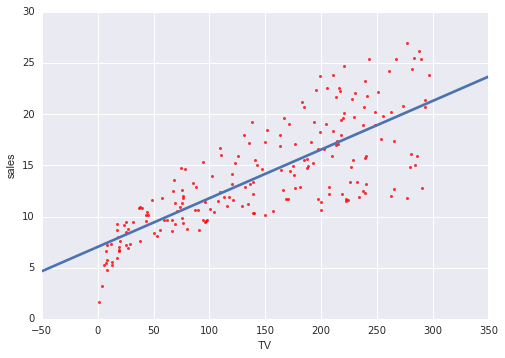

In [66]:
import seaborn as sns
sns.regplot(advertising.TV, advertising.sales, order=1, ci=True, scatter_kws={'color':'r', 's':9})

In [82]:
from sklearn import datasets ## imports datasets from scikit-learn
data = datasets.load_boston() ## loads Boston dataset from datasets
# define the data/predictors as the pre-set feature names  
df = pd.DataFrame(data.data, columns=data.feature_names)
# Put the target (housing value -- MEDV) in another DataFrame
target = pd.DataFrame(data.target, columns=["MEDV"])

In [89]:
model = sk_lm.LinearRegression(fit_intercept=True)

In [90]:
lm_results = model.fit(df,target)

In [99]:
lm_results.score(df,target)

0.7406077428649428

In [95]:
import statsmodels.api as sm

In [101]:
X = sm.add_constant(df) ## let's add an intercept (beta_0) to our model

# Note the difference in argument order
model = sm.OLS(target, X).fit() ## sm.OLS(output, input)
predictions = model.predict(X)
# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 10 Jul 2018   Prob (F-statistic):          6.95e-135
Time:                        21:59:00   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4911      5.104      7.149      0.000      26.462      46.520
CRIM          -0.1072      0.033     -3.276      0.001      -0.171      -0.043
ZN             0.0464      0.014      3.380      0.001       0.019       0.073
INDUS          0.0209      0.061      0.339      0.735      -0.100       0.142
CHAS           2.6886      0.862      3.120      0.002       0.996       4.381
NOX          -17.7958      3.821     -4.658      0.000     -25.302     -10.289
RM             3.8048      0.418      9.102      0.000       2.983       4.626
AGE            0.0008      0.013      0.057      0.955      -0.025       0.027
DIS           -1.4758      0.199     -7.398      0.000      -1.868      -1.084
RAD            0.3057      0.066      4.608      0.000       0.175       0.436
TAX           -0.0123      0.004     -3.278      0.001      -0.020      -0.005
PTRATIO       -0.9535      0.131     -7.287      0.000      -1.211      -0.696
B              0.0094      0.003      3.500      0.001       0.004       0.015
LSTAT         -0.5255      0.051    -10.366      0.000      -0.625      -0.426
==============================================================================
Omnibus:                      178.029   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              782.015
Skew:                           1.521   Prob(JB):                    1.54e-170
Kurtosis:                       8.276   Cond. No.                     1.51e+04
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""